In [2]:
# Deploying necessary libraries
import numpy as np
import numpy.linalg as la
import networkx as nx
import matplotlib.pyplot as plt
import string
%matplotlib inline

In [3]:
# Labels for 50 nodes
labels = list(string.ascii_uppercase)
labels += [f"A{c}" for c in string.ascii_uppercase[:24]]  # total 50
n = 50
# Adjacency matrix
adj_matrix = np.zeros((n, n), dtype=int)
np.random.seed(42)
for i in range(n):
    num_links = np.random.randint(1, 11)  # 1 to 10 links
    links = np.random.choice([x for x in range(n) if x != i], num_links, replace=False)
    adj_matrix[i, links] = 1
# Convert to stochastic matrix
L = np.zeros((n, n), dtype=float)
for i in range(n):
    row_sum = adj_matrix[i].sum()
    if row_sum > 0:
        L[i] = adj_matrix[i] / row_sum
    else:
        L[i] = np.ones(n)/n  # dangling node
# Apply damping factor
d = 0.85
L_hat = d*L + (1-d)/n * np.ones((n,n))
# Print final stochastic matrix
print(L_hat)

[[0.003      0.003      0.003      ... 0.003      0.003      0.12442857]
 [0.088      0.003      0.003      ... 0.003      0.003      0.003     ]
 [0.003      0.28633333 0.003      ... 0.003      0.003      0.28633333]
 ...
 [0.003      0.003      0.003      ... 0.003      0.003      0.003     ]
 [0.003      0.003      0.003      ... 0.003      0.003      0.003     ]
 [0.003      0.003      0.003      ... 0.003      0.003      0.003     ]]


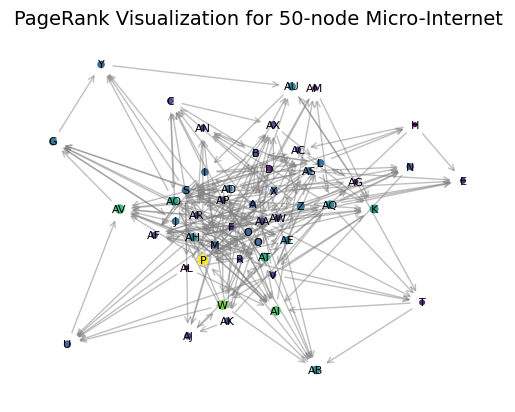

In [10]:
# Create directed graph from adjacency matrix
G = nx.DiGraph(adj_matrix)
# Compute positions (layout)
pos = nx.spring_layout(G, seed=42)  # spring layout looks nice
# Node sizes proportional to PageRank
node_sizes = RankPoints * 10  # adjust scaling factor if needed
# Optional: node colors based on rank (higher rank = darker color)
max_rank = max(RankPoints)
node_colors = [score / max_rank for score in RankPoints]
# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.9
)
# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=10, edge_color='gray', alpha=0.5)
# Draw labels
nx.draw_networkx_labels(G, pos, labels={i: label for i, label in enumerate(labels)}, font_size=8)
# Title
plt.title("PageRank Visualization for 50-node Micro-Internet", fontsize=14)
# Remove axes
plt.axis('off')
# Show plot
plt.show()

In [4]:
#FIXED ITERATION METHOD
n = L.shape[0]  # Number of pages
d = 0.85        # Damping factor
# Handle dangling nodes
for i in range(n):
    if L[i].sum() == 0:
        L[i] = np.ones(n) / n
# Apply damping factor
L_hat = d * L + (1-d)/n * np.ones((n, n))
# Initialize PageRank vector
PR = np.ones(n) / n
# Power iteration with convergence
epsilon = 1e-6
for _ in range(1000):
    PR_new = L_hat.T @ PR
    if np.linalg.norm(PR_new - PR, 1) < epsilon:
        break
    PR = PR_new
# Normalize and scale
RankPoints = 100 * PR / np.sum(PR)
# Print sorted PageRank
print("PageRank (micro-internet) for 50 pages:")
for label, score in sorted(zip(labels, RankPoints), key=lambda x: x[1], reverse=True):
    print(f"{label}: {score:.2f}")

PageRank (micro-internet) for 50 pages:
P: 4.97
W: 4.17
AI: 3.79
AV: 3.59
AT: 3.28
AO: 3.21
K: 2.96
AQ: 2.68
AB: 2.62
AH: 2.59
AU: 2.53
Z: 2.35
AE: 2.31
G: 2.23
J: 2.17
L: 2.16
AD: 2.14
S: 2.09
I: 2.03
AS: 2.02
X: 2.02
Y: 2.01
Q: 2.01
O: 1.95
U: 1.88
M: 1.82
B: 1.81
N: 1.81
AK: 1.75
A: 1.69
AJ: 1.68
AF: 1.65
C: 1.59
AX: 1.56
AA: 1.45
AP: 1.41
V: 1.41
AC: 1.39
AN: 1.38
R: 1.34
AR: 1.30
AW: 1.27
E: 1.20
F: 1.17
T: 1.14
D: 1.07
AM: 0.96
AG: 0.95
H: 0.74
AL: 0.73


In [5]:
#CONVERGENCE BASED METHOD
n = L.shape[0]
d = 0.85
epsilon = 1e-6
max_iter = 1000
# Handle dangling nodes and damping factor
for i in range(n):
    if L[i].sum() == 0:
        L[i] = np.ones(n)/n
L_hat = d * L + (1-d)/n * np.ones((n, n))
# Initialize
PR = np.ones(n)/n
delta = 1
iteration = 0
while delta > epsilon and iteration < max_iter:
    PR_new = L_hat.T @ PR
    delta = np.linalg.norm(PR_new - PR, 1)  # L1 norm
    PR = PR_new
    iteration += 1
print(f"Converged in {iteration} iterations")
# Scale and sort PageRank
RankPoints = 100 * PR / np.sum(PR)
for label, score in sorted(zip(labels, RankPoints), key=lambda x: x[1], reverse=True):
    print(f"{label}: {score:.2f}")

Converged in 17 iterations
P: 4.97
W: 4.17
AI: 3.79
AV: 3.59
AT: 3.28
AO: 3.21
K: 2.96
AQ: 2.68
AB: 2.62
AH: 2.59
AU: 2.53
Z: 2.35
AE: 2.31
G: 2.23
J: 2.17
L: 2.16
AD: 2.14
S: 2.09
I: 2.03
AS: 2.02
X: 2.02
Y: 2.01
Q: 2.01
O: 1.95
U: 1.88
M: 1.82
B: 1.81
N: 1.81
AK: 1.75
A: 1.69
AJ: 1.68
AF: 1.65
C: 1.59
AX: 1.56
AA: 1.45
AP: 1.41
V: 1.41
AC: 1.39
AN: 1.38
R: 1.34
AR: 1.30
AW: 1.27
E: 1.20
F: 1.17
T: 1.14
D: 1.07
AM: 0.96
AG: 0.95
H: 0.74
AL: 0.73


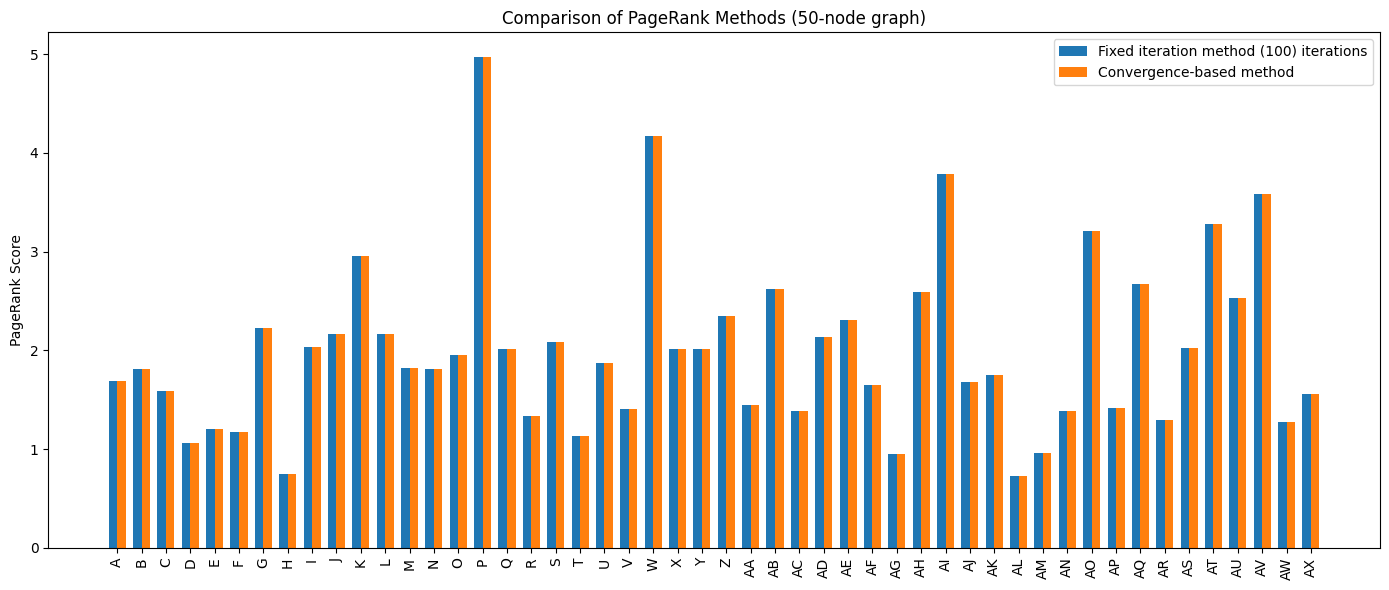

In [6]:
# --- First implementation: fixed 100 iterations ---
PR_fixed = np.ones(n) / n
for _ in range(100):
    PR_fixed = L_hat.T @ PR_fixed
RankPoints_fixed = 100 * PR_fixed / np.sum(PR_fixed)

# --- Second implementation: convergence-based ---
PR_conv = np.ones(n) / n
epsilon = 1e-6
delta = 1
iteration = 0
while delta > epsilon:
    PR_new = L_hat.T @ PR_conv
    delta = np.linalg.norm(PR_new - PR_conv, 1)
    PR_conv = PR_new
    iteration += 1
RankPoints_conv = 100 * PR_conv / np.sum(PR_conv)

# --- Plot comparison ---
x = np.arange(n)  # node indices
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, RankPoints_fixed, width, label='Fixed iteration method (100) iterations')
plt.bar(x + width/2, RankPoints_conv, width, label='Convergence-based method')

plt.xticks(x, labels, rotation=90)
plt.ylabel("PageRank Score")
plt.title("Comparison of PageRank Methods (50-node graph)")
plt.legend()
plt.tight_layout()
plt.show()

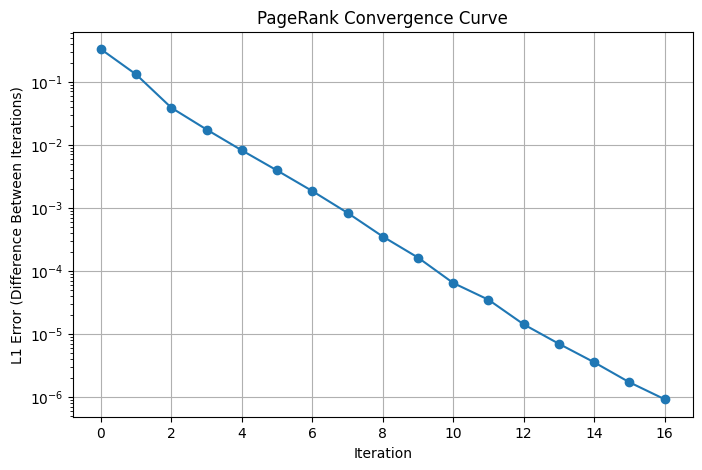

In [11]:
# --- Convergence analysis for PageRank ---
# This will help to tracks how the PageRank vector stabilizes over iterations

# Initialize PageRank vector with equal probability
PR_conv = np.ones(n) / n
epsilon = 1e-6
delta = 1
iteration = 0

errors = []
iterations_list = []

# Iteratively update PageRank until convergence
while delta > epsilon: 
    PR_new = L_hat.T @ PR_conv   
    delta = np.linalg.norm(PR_new - PR_conv, 1)   
    errors.append(delta)
    iterations_list.append(iteration)    
    PR_conv = PR_new   
    iteration += 1

# --- Plot convergence curve ---
# This plot shows how the error decreases as the algorithm converges
plt.figure(figsize=(8,5))
plt.plot(iterations_list, errors, marker='o')
plt.xlabel("Iteration")
plt.ylabel("L1 Error (Difference Between Iterations)")
plt.title("PageRank Convergence Curve")
plt.yscale("log")
plt.grid(True)
plt.show()

##COMPARISON BETWEEN MANUAL PAGERANK AND NETWORK X PAGE RANK


In [9]:
# --- 1. Define a small 4-node graph ---
# A -> B, B -> C, C -> A, D -> C
adj_matrix_small = np.array([
    [0, 1, 0, 0],  # A
    [0, 0, 1, 0],  # B
    [1, 0, 0, 0],  # C
    [0, 0, 1, 0]   # D
], dtype=float)

labels_small = ['A', 'B', 'C', 'D']
n_small = adj_matrix_small.shape[0]
d = 0.85
epsilon = 1e-6

# --- 2. Handle dangling nodes ---
for i in range(n_small):
    if adj_matrix_small[i].sum() == 0:
        adj_matrix_small[i] = np.ones(n_small) / n_small

# --- 3. Convert to stochastic matrix with damping factor ---
L_hat_small = d * (adj_matrix_small / adj_matrix_small.sum(axis=1, keepdims=True)) \
              + (1 - d) / n_small * np.ones((n_small, n_small))

# --- 4. Manual power iteration (convergence-based) ---
PR = np.ones(n_small) / n_small
delta = 1
iteration = 0
while delta > epsilon:
    PR_new = L_hat_small.T @ PR
    delta = np.linalg.norm(PR_new - PR, 1)
    PR = PR_new
    iteration += 1

print(f"Manual PageRank converged in {iteration} iterations")
for label, score in zip(labels_small, 100*PR/PR.sum()):
    print(f"{label}: {score:.2f}")

# --- 5. Compare with NetworkX ---
G_small = nx.DiGraph()
G_small.add_edges_from([('A','B'), ('B','C'), ('C','A'), ('D','C')])
pr_nx = nx.pagerank(G_small, alpha=d)
print("\nNetworkX PageRank:")
for label, score in pr_nx.items():
    print(f"{label}: {score*100:.2f}")

Manual PageRank converged in 81 iterations
A: 32.02
B: 30.97
C: 33.26
D: 3.75

NetworkX PageRank:
A: 32.02
B: 30.97
C: 33.26
D: 3.75
